# Смешанная модель: сценарии с отрицательной γ (рост потенциала)

Исследуется смешанная (комбинированная) модель:

$$
X_{n+1}=X_n + q X_n (K - X_n - \gamma X_{n-1}), \quad K=1
$$

Ненулевая особая точка (потенциал развития) при стационарности $X_{n+1}=X_n=X_{n-1}=X^*$:

$$
X^* = \frac{1}{1+\gamma}
$$

Следовательно:
- при $\gamma>0$ потенциал $X^*<1$;
- при $-1<\gamma<0$ потенциал $X^*>1$, т.е. предыстория **увеличивает** потенциальный уровень развития.


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)


In [41]:
# параметры “как в дипломе”
K = 1.0
steps = 220
x0 = 1e-4

# те же q, что ты уже использовал, чтобы было сравнение “яблоко с яблоком”
q_list = [1.5, 2.8, 3.1]

# главное: отрицательные gamma (и один “пограничный” для демонстрации)
gamma_list = [-0.2, -0.5, -0.8, -1.1]   # -1.1 можно оставить как “крайний случай”


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# =========================================================
# 1) Mixed-модель (7.2): x_{n+1} = x_n + x_n*q*(1 - x_n - gamma*x_{n-1})
# =========================================================
def generate_mixed_process(q, gamma, x0=1e-4, steps=200, clip_hi=10.0):
    x = np.zeros(steps, dtype=float)
    x[0] = x0
    # стартовый разгон: используем x1 по формуле с x_{-1} ~ x0
    x[1] = x[0] + x[0] * q * (1 - x[0] - gamma * x[0])

    for i in range(1, steps - 1):
        term = (1 - x[i] - gamma * x[i - 1])
        x[i + 1] = x[i] + x[i] * q * term

        # тех. ограничители (комментарий в тексте диплома: "ограничение вычислительное")
        if x[i + 1] < 0:
            x[i + 1] = 0.0
        if x[i + 1] > clip_hi:
            x[i + 1] = clip_hi

    return x

# =========================================================
# 2) ω и матрица лагов: ω_{n+1} = (x_{n+1} - x_n) / x_n
# =========================================================
def make_regression_df(x, lags=10):
    x = np.asarray(x, dtype=float)
    xn = x[:-1]
    xn1 = x[1:]

    safe = xn.copy()
    safe[safe == 0] = 1e-12
    omega = (xn1 - xn) / safe

    df = pd.DataFrame({"omega": omega, "X_n": xn})
    for l in range(1, lags + 1):
        df[f"Lag_{l}"] = pd.Series(xn).shift(l)

    df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return df

# =========================================================
# 3) Stepwise (SPSS-like) по p-values
# =========================================================
def stepwise_selection(X, y, initial_list=None, threshold_in=0.01, threshold_out=0.05, max_steps=200):
    if initial_list is None:
        initial_list = []
    included = list(initial_list)

    steps = 0
    while steps < max_steps:
        steps += 1
        changed = False

        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)

        # forward
        for col in excluded:
            try:
                model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
                new_pval[col] = model.pvalues[col]
            except Exception:
                continue

        if not new_pval.empty:
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True

        # backward
        if included:
            try:
                model = sm.OLS(y, sm.add_constant(X[included])).fit()
                pvals = model.pvalues.iloc[1:]  # без const
                if not pvals.empty and pvals.max() > threshold_out:
                    worst_feature = pvals.idxmax()
                    included.remove(worst_feature)
                    changed = True
            except Exception:
                pass

        if not changed:
            break

    return included

# =========================================================
# 4) ENTER + Beta (с защитой от нулевой дисперсии)
# =========================================================
def fit_enter_with_beta(X_mat, y):
    # OLS ENTER (можно оставить даже с константными колонками — statsmodels обычно переживает)
    Xc = sm.add_constant(X_mat, has_constant="add")
    model = sm.OLS(y, Xc).fit()

    # Beta: стандартизация (убираем нулевую дисперсию)
    std = X_mat.std(ddof=0)
    good_cols = std[std > 0].index.tolist()

    # <<< FIX: если все признаки константны >>>
    if len(good_cols) == 0:
        beta = pd.Series(dtype=float)
        return model, beta

    Xs = (X_mat[good_cols] - X_mat[good_cols].mean()) / X_mat[good_cols].std(ddof=0)

    y_std = y.std(ddof=0)
    ys = (y - y.mean()) / (y_std if y_std > 0 else 1.0)

    beta_model = sm.OLS(ys, Xs).fit()
    beta = pd.Series(beta_model.params, index=good_cols)

    return model, beta


# =========================================================
# 5) Стадии "жизненного цикла" (для режима роста)
# =========================================================
def find_lifecycle_stages(x, K=1.0, min_points=15):
    x = np.asarray(x, dtype=float)
    stages = {}

    idx1 = np.where(x < 0.1 * K)[0]
    idx2 = np.where((x >= 0.1 * K) & (x < 0.5 * K))[0]
    idx3 = np.where((x >= 0.5 * K) & (x < 0.95 * K))[0]
    idx4 = np.where(x >= 0.95 * K)[0]

    def bounds(idx):
        if len(idx) < min_points:
            return None
        return (idx[0], idx[-1] + 1)

    if len(idx1) > 0: stages["1. Зарождение (<10%)"] = bounds(idx1)
    if len(idx2) > 0: stages["2. Активный рост (10-50%)"] = bounds(idx2)
    if len(idx3) > 0: stages["3. Насыщение (50-95%)"] = bounds(idx3)
    if len(idx4) > 0: stages["4. Плато (>95%)"] = bounds(idx4)

    return stages

def stagewise_analysis(x, stages, lags=10):
    rows = []
    for name, b in stages.items():
        if b is None:
            continue
        s, e = b
        seg = x[s:e]
        df = make_regression_df(seg, lags=lags)
        if len(df) < 8:
            continue

        y = df["omega"]
        X_mat = df.drop(columns=["omega"])

        # ENTER
        enter_model, enter_beta = fit_enter_with_beta(X_mat, y)

        # STEPWISE
        sel = stepwise_selection(X_mat, y)
        step_r2 = np.nan
        if sel:
            step_model = sm.OLS(y, sm.add_constant(X_mat[sel])).fit()
            step_r2 = step_model.rsquared

        rows.append({
            "stage": name,
            "interval": f"{s}-{e}",
            "n_obs": len(df),
            "ENTER_R2": enter_model.rsquared,
            "ENTER_B_Xn": enter_model.params.get("X_n", np.nan),
            "ENTER_B_Lag1": enter_model.params.get("Lag_1", np.nan),
            "ENTER_Beta_Xn": enter_beta.get("X_n", np.nan),
            "ENTER_Beta_Lag1": enter_beta.get("Lag_1", np.nan),
            "STEP_selected": sel,
            "STEP_R2": step_r2
        })

    return pd.DataFrame(rows)

# =========================================================
# 6) Скользящее окно: ENTER/STEPWISE + дрейф коэффициентов
# =========================================================
def rolling_window_regression(x, window=25, lags=10, method="enter"):
    x = np.asarray(x, dtype=float)
    rows = []
    min_len = lags + 8
    if window < min_len:
        raise ValueError(f"window must be >= {min_len} for lags={lags}")

    for start in range(0, len(x) - window):
        end = start + window
        seg = x[start:end]
        df = make_regression_df(seg, lags=lags)
        if len(df) < 8:
            continue

        y = df["omega"]
        X_mat = df.drop(columns=["omega"])

        if method == "enter":
            model, beta = fit_enter_with_beta(X_mat, y)
            selected = list(X_mat.columns)

        elif method == "stepwise":
            selected = stepwise_selection(X_mat, y)
            if not selected:
                continue
            model = sm.OLS(y, sm.add_constant(X_mat[selected])).fit()
            # beta для выбранных (защита от нулевой дисперсии)
            std = X_mat[selected].std(ddof=0)
            good = std[std > 0].index.tolist()
            Xs = (X_mat[good] - X_mat[good].mean()) / X_mat[good].std(ddof=0)
            ys = (y - y.mean()) / (y.std(ddof=0) if y.std(ddof=0) > 0 else 1.0)
            beta_model = sm.OLS(ys, Xs).fit()
            beta = pd.Series(beta_model.params, index=good)

        else:
            raise ValueError("method must be 'enter' or 'stepwise'")

        row = {"start": start, "end": end, "R2": model.rsquared, "selected": selected}

        # B-коэффициенты
        for k, v in model.params.items():
            row[f"B_{k}"] = v

        # Beta-коэффициенты
        for k, v in beta.items():
            row[f"Beta_{k}"] = v

        rows.append(row)

    # <<< FIX: всегда возвращаем DF с ожидаемыми колонками >>>
    base_cols = ["start", "end", "R2", "selected"]
    out = pd.DataFrame(rows)
    for c in base_cols:
        if c not in out.columns:
            out[c] = pd.Series(dtype=object if c == "selected" else float)
    return out


def stepwise_frequency(roll_step, lags=10):
    cols = ["X_n"] + [f"Lag_{i}" for i in range(1, lags + 1)]
    cnt = {c: 0 for c in cols}

    if roll_step is None or len(roll_step) == 0 or "selected" not in roll_step.columns:
        return pd.DataFrame({"var": list(cnt.keys()), "count": list(cnt.values())}).sort_values("count", ascending=False)

    for sel in roll_step["selected"].dropna():
        for v in sel:
            if v in cnt:
                cnt[v] += 1

    return pd.DataFrame({"var": list(cnt.keys()), "count": list(cnt.values())}).sort_values("count", ascending=False)


In [44]:
def theoretical_coeffs(q, gamma):
    # omega = q - q*X_n - q*gamma*X_{n-1}
    return {"B_X_n_theory": -q, "B_Lag1_theory": -q*gamma}

def fixed_point(gamma):
    # X* = 1/(1+gamma), если gamma != -1
    if abs(1+gamma) < 1e-12:
        return np.nan
    return 1.0/(1.0+gamma)


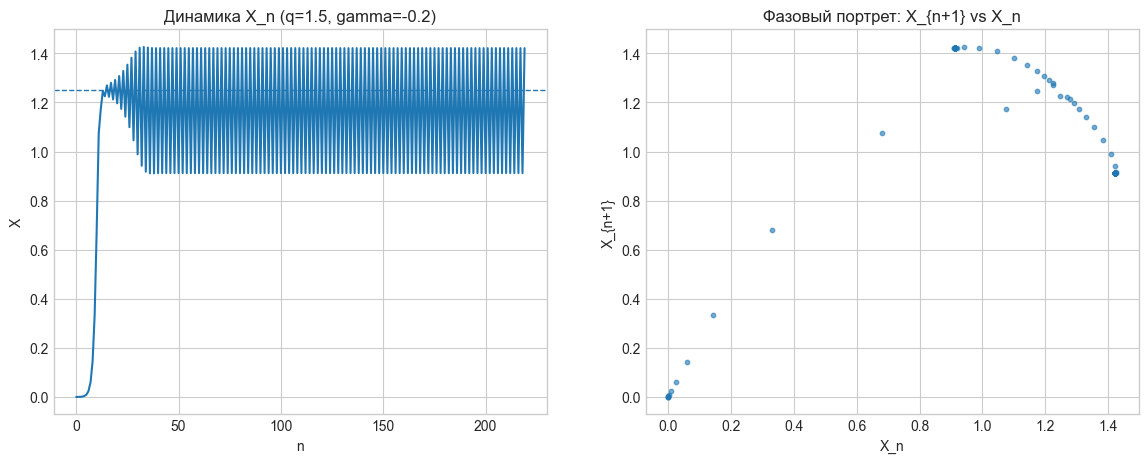

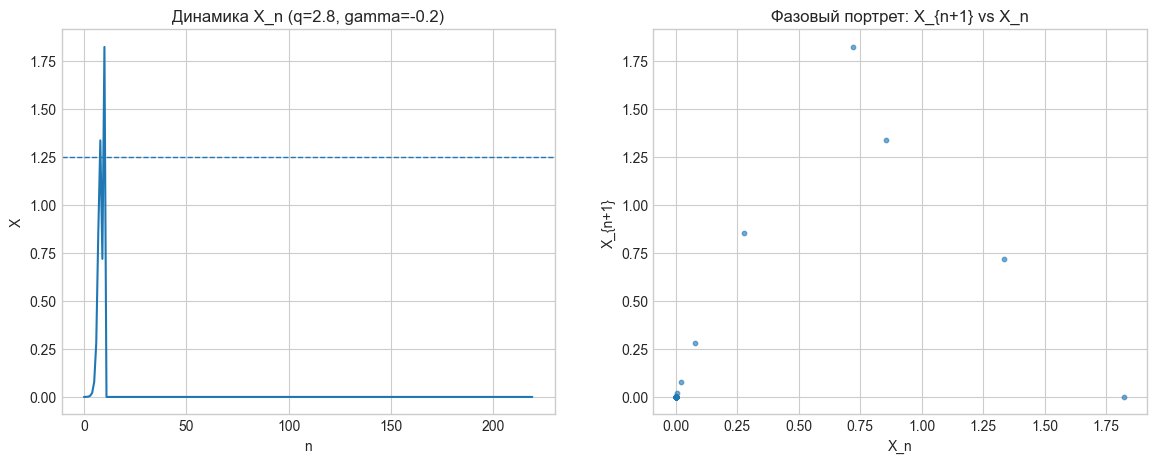

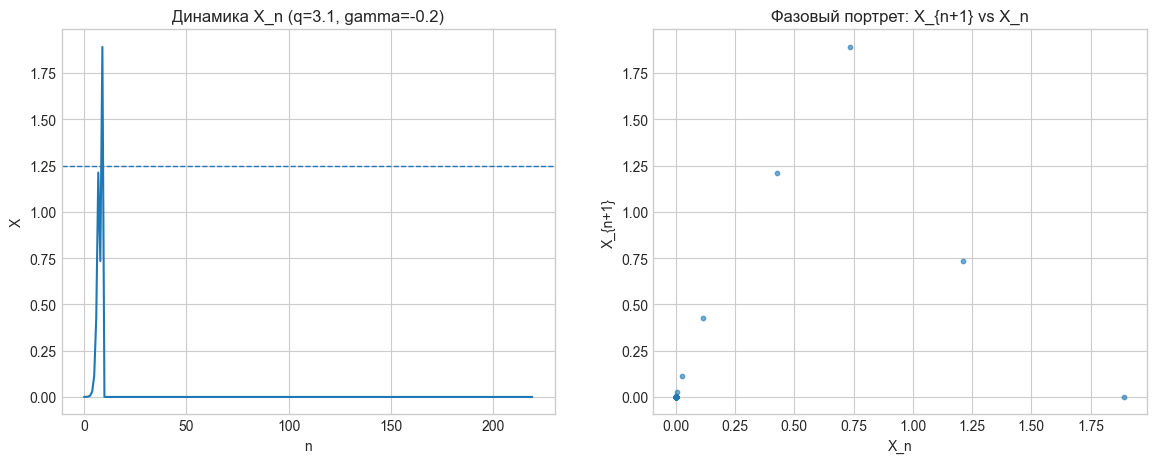

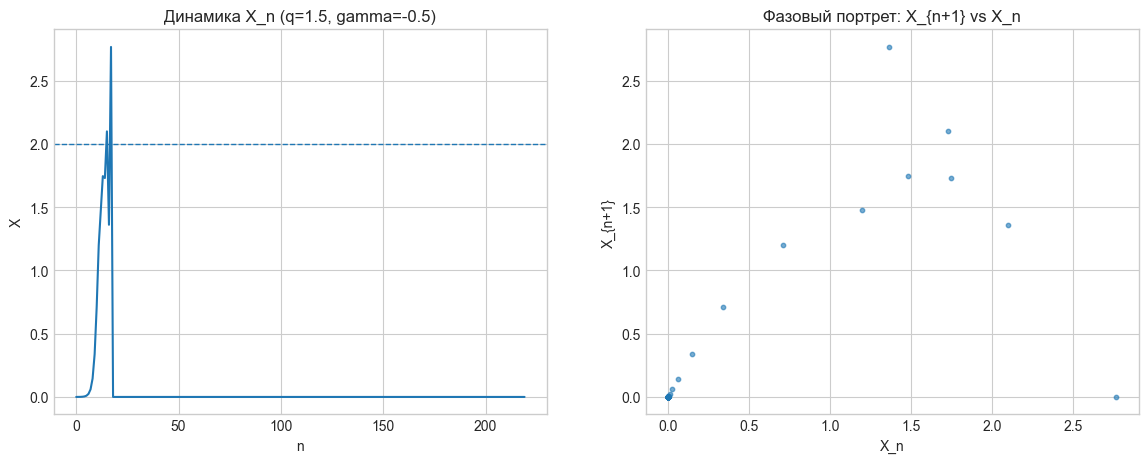

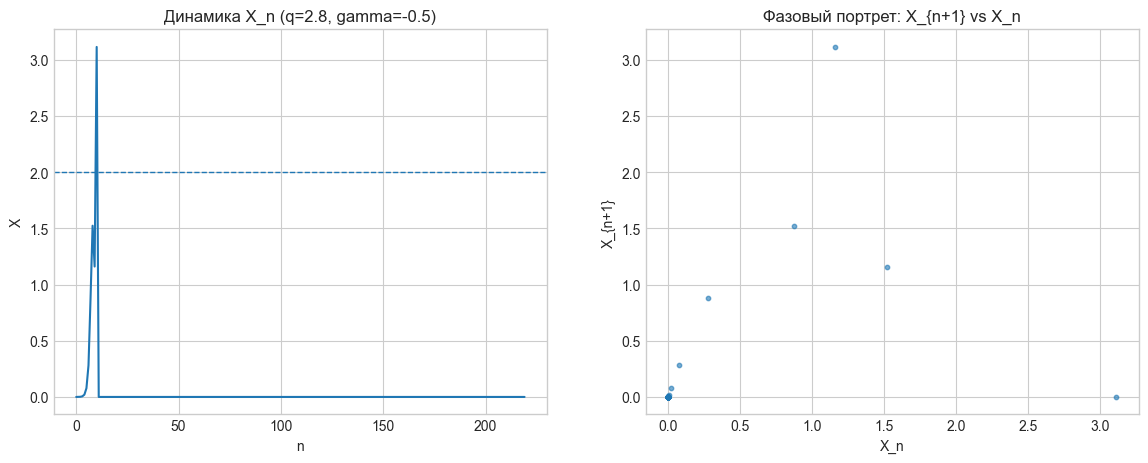

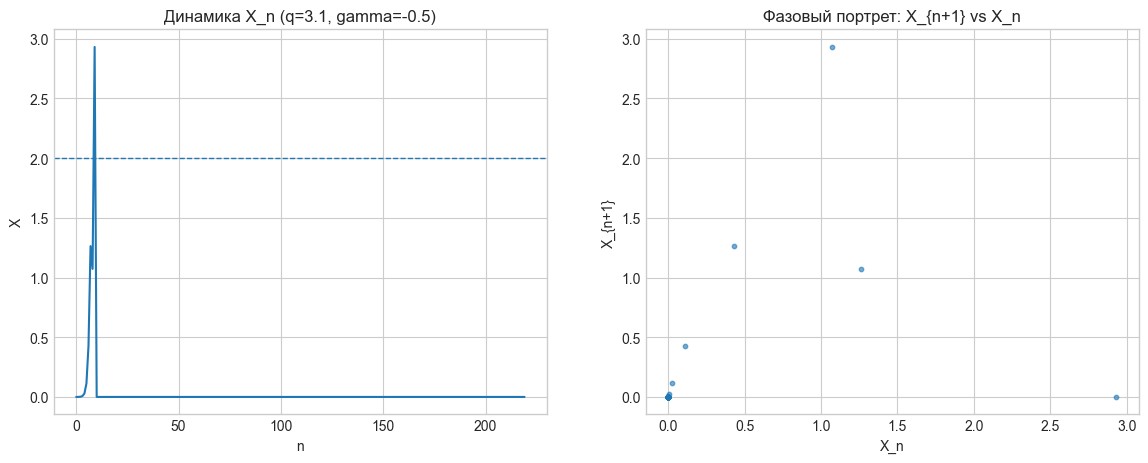

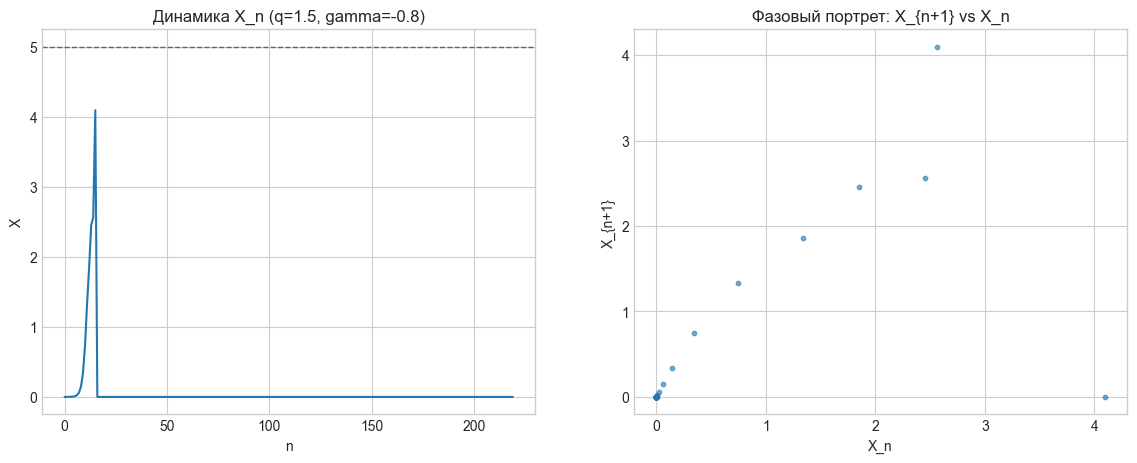

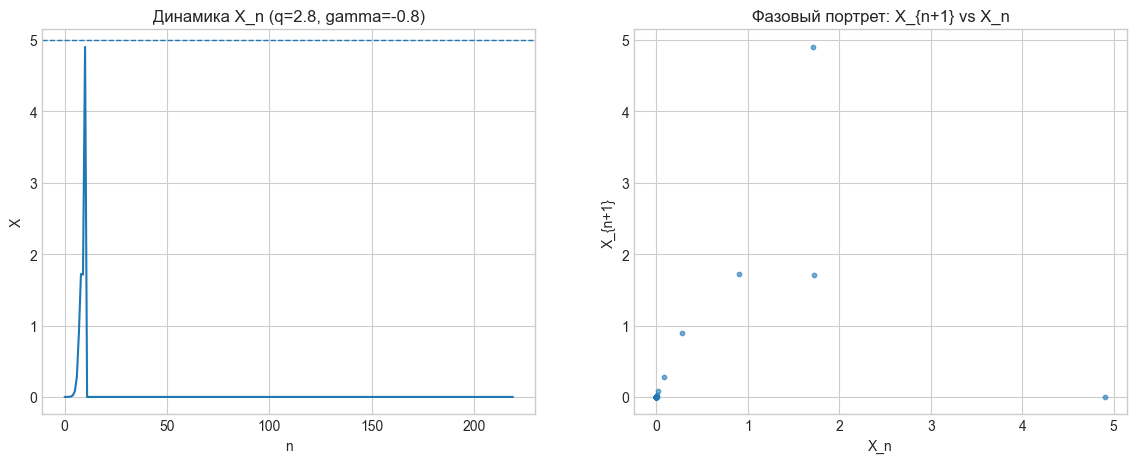

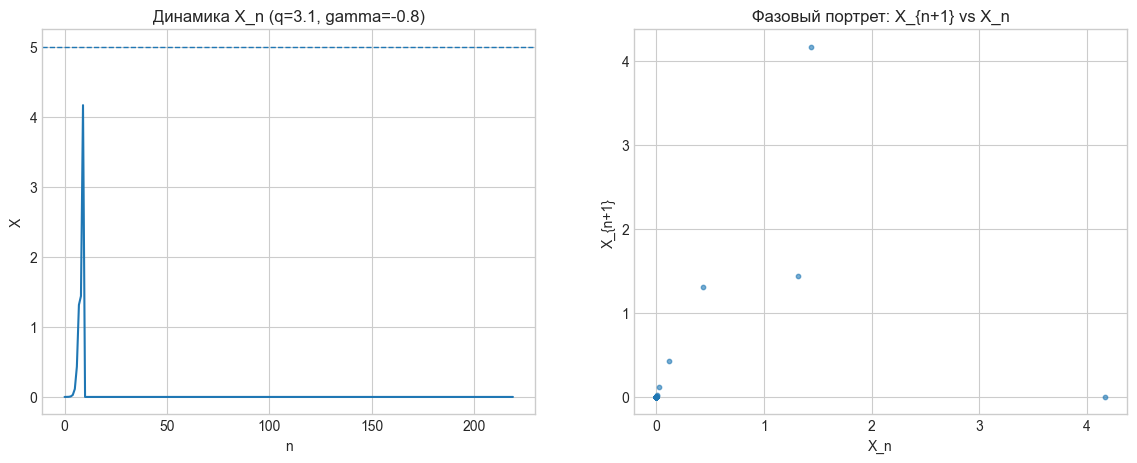

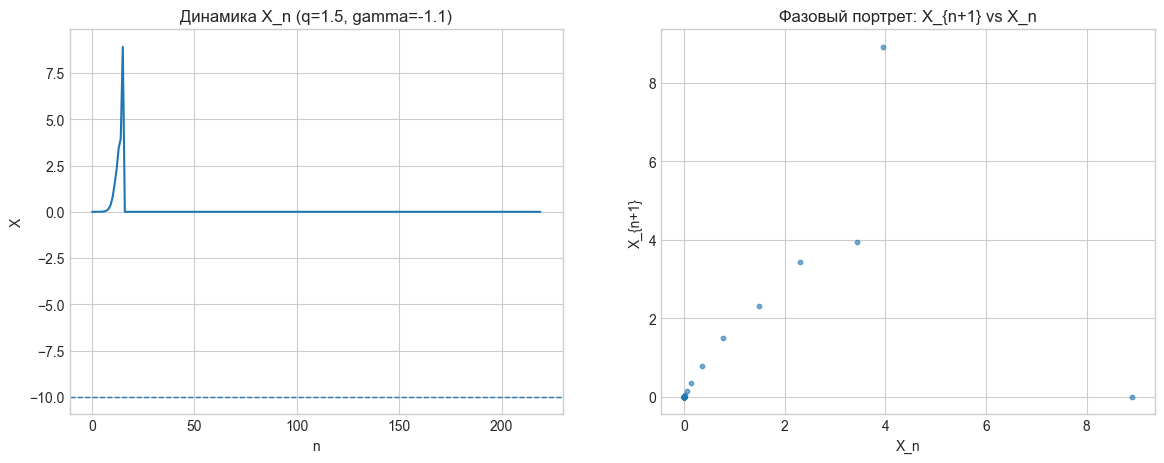

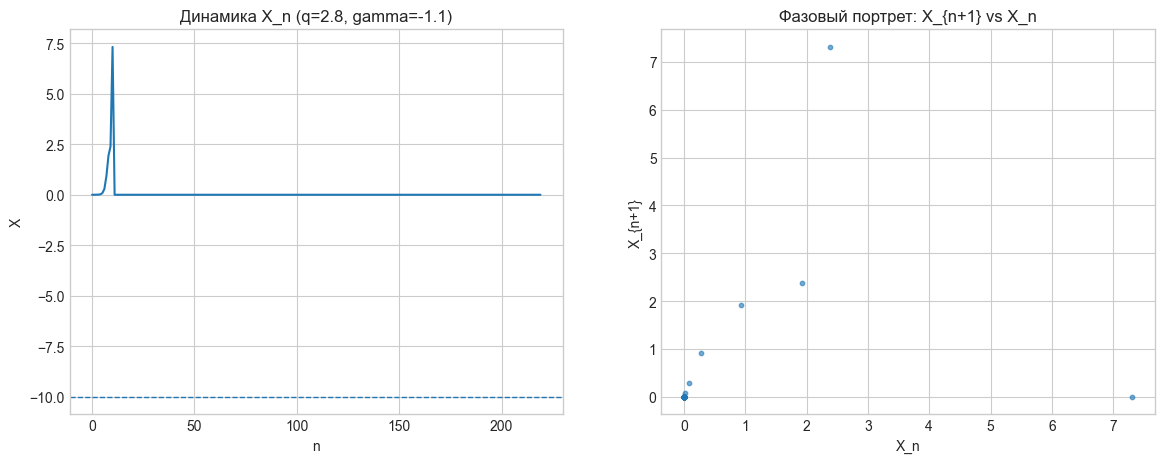

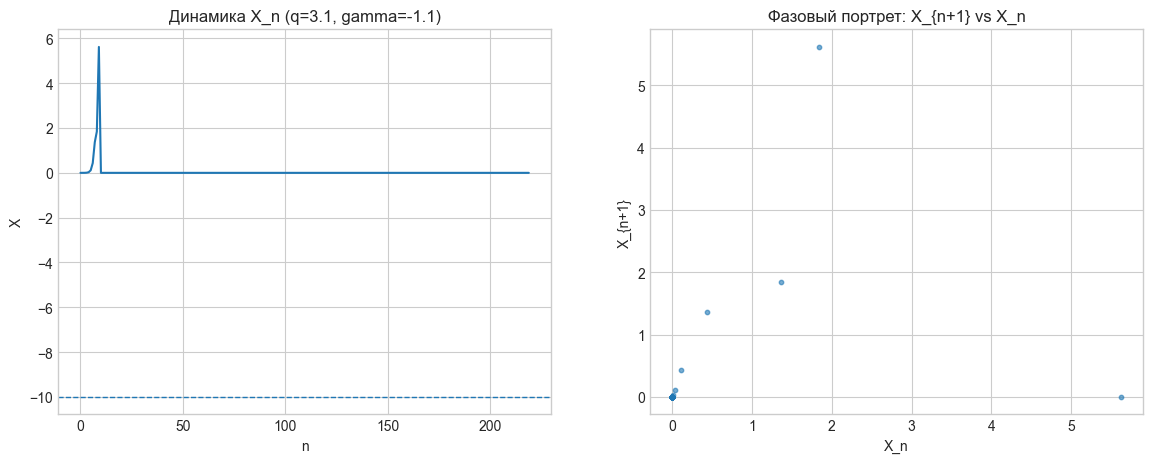

In [45]:
for gamma in gamma_list:
    for q in q_list:
        x = generate_mixed_process(q=q, gamma=gamma, x0=x0, steps=steps, clip_hi=10.0)

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        ax[0].plot(x, lw=1.5)
        ax[0].set_title(f"Динамика X_n (q={q}, gamma={gamma})")
        ax[0].set_xlabel("n"); ax[0].set_ylabel("X")

        ax[1].scatter(x[:-1], x[1:], s=10, alpha=0.6)
        ax[1].set_title("Фазовый портрет: X_{n+1} vs X_n")
        ax[1].set_xlabel("X_n"); ax[1].set_ylabel("X_{n+1}")

        fp = fixed_point(gamma)
        ax[0].axhline(fp, ls="--", lw=1)
        plt.show()


In [46]:
rows = []
lags = 10

for gamma in gamma_list:
    for q in q_list:
        x = generate_mixed_process(q=q, gamma=gamma, x0=x0, steps=steps, clip_hi=10.0)
        df = make_regression_df(x, lags=lags)

        y = df["omega"]
        X_mat = df.drop(columns=["omega"])

        enter_model, enter_beta = fit_enter_with_beta(X_mat, y)
        th = theoretical_coeffs(q, gamma)

        rows.append({
            "q": q, "gamma": gamma,
            "R2": enter_model.rsquared,
            "B_X_n": enter_model.params.get("X_n", np.nan),
            "B_Lag_1": enter_model.params.get("Lag_1", np.nan),
            "Beta_X_n": enter_beta.get("X_n", np.nan),
            "Beta_Lag_1": enter_beta.get("Lag_1", np.nan),
            "B_X_n_theory": th["B_X_n_theory"],
            "B_Lag1_theory": th["B_Lag1_theory"],
            "X_star": fixed_point(gamma)
        })

summary = pd.DataFrame(rows)
summary


/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,q,gamma,R2,B_X_n,B_Lag_1,Beta_X_n,Beta_Lag_1,B_X_n_theory,B_Lag1_theory,X_star
0,1.5,-0.2,1.000000,-1.500000,3.000000e-01,-0.841232,1.723891e-01,-1.5,0.30,1.25
1,2.8,-0.2,1.000000,-0.548682,-2.046378e-16,-1.000000,-4.284767e-16,-2.8,0.56,1.25
2,3.1,-0.2,NaN,0.000000,0.000000e+00,NaN,0.000000e+00,-3.1,0.62,1.25
3,1.5,-0.5,0.157673,-0.164583,2.413161e-01,-0.475342,6.980304e-01,-1.5,0.75,2.00
4,2.8,-0.5,1.000000,-0.321057,-6.741971e-16,-1.000000,-3.616898e-16,-2.8,1.40,2.00
5,3.1,-0.5,NaN,0.000000,0.000000e+00,NaN,0.000000e+00,-3.1,1.55,2.00
6,1.5,-0.8,0.034053,-0.041935,5.808406e-02,-0.164083,2.275193e-01,-1.5,1.20,5.00
7,2.8,-0.8,1.000000,-0.203996,-3.793802e-16,-1.000000,2.623769e-16,-2.8,2.24,5.00
8,3.1,-0.8,NaN,0.000000,0.000000e+00,NaN,0.000000e+00,-3.1,2.48,5.00
9,1.5,-1.1,0.025057,-0.024459,3.492843e-02,-0.130734,1.867365e-01,-1.5,1.65,-10.00


In [47]:
q = 1.5
for gamma in [-0.2, -0.5, -0.8]:
    x = generate_mixed_process(q=q, gamma=gamma, x0=x0, steps=steps, clip_hi=10.0)
    stages = find_lifecycle_stages(x, K=K, min_points=15)
    st_table = stagewise_analysis(x, stages, lags=10)
    print(f"\n==== Stagewise (q={q}, gamma={gamma}) | X*={fixed_point(gamma):.3f} ====")
    display(st_table)



==== Stagewise (q=1.5, gamma=-0.2) | X*=1.250 ====


,stage,interval,n_obs,ENTER_R2,ENTER_B_Xn,ENTER_B_Lag1,ENTER_Beta_Xn,ENTER_Beta_Lag1,STEP_selected,STEP_R2
0,3. Насыщение (50-95%),10-219,198,1.0,-1.5,0.3,-0.834576,0.166589,"[X_n, Lag_1, Lag_10, Lag_6]",1.0
1,4. Плато (>95%),11-220,198,1.0,-1.5,0.3,-0.834570,0.166469,"[X_n, Lag_1]",1.0



==== Stagewise (q=1.5, gamma=-0.5) | X*=2.000 ====


,stage,interval,n_obs,ENTER_R2,ENTER_B_Xn,ENTER_B_Lag1,ENTER_Beta_Xn,ENTER_Beta_Lag1,STEP_selected,STEP_R2
0,1. Зарождение (<10%),0-220,209,0.157673,-0.164583,0.241316,-0.475342,0.69803,[],NaN



==== Stagewise (q=1.5, gamma=-0.8) | X*=5.000 ====


,stage,interval,n_obs,ENTER_R2,ENTER_B_Xn,ENTER_B_Lag1,ENTER_Beta_Xn,ENTER_Beta_Lag1,STEP_selected,STEP_R2
0,1. Зарождение (<10%),0-220,209,0.034053,-0.041935,0.058084,-0.164083,0.227519,[],NaN


In [49]:
def print_window_summary(q_val, roll_enter, roll_step):
    print(f"\n--- SUMMARY (q={q_val}, gamma={gamma}, window={window}, lags={lags}) ---")

    # 1) Первые 5 окон (R2 + ключевые коэффициенты)
    cols_show = ["start", "end", "R2", "B_X_n", "B_Lag_1", "B_sum_lags"]
    cols_show = [c for c in cols_show if c in roll_enter.columns]
    print("\nENTER head (первые 5 окон):")
    print(roll_enter[cols_show].head(5).to_string(index=False))

    # 2) Сводка по R2
    print("\nENTER R2 describe:")
    print(roll_enter["R2"].describe().to_string())

    # 3) Средние/медианы ключевых B
    def safe_stat(col):
        if col not in roll_enter.columns:
            return None
        s = roll_enter[col].replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) == 0:
            return None
        return {
            "mean": float(s.mean()),
            "median": float(s.median()),
            "std": float(s.std(ddof=0)),
            "min": float(s.min()),
            "max": float(s.max()),
        }

    for c in ["B_X_n", "B_Lag_1", "B_sum_lags"]:
        st = safe_stat(c)
        if st is None:
            print(f"\n{c}: no data")
        else:
            print(f"\n{c}: mean={st['mean']:.4f} | median={st['median']:.4f} | "
                  f"std={st['std']:.4f} | min={st['min']:.4f} | max={st['max']:.4f}")

    # 4) Stepwise: сколько окон и какие переменные выбирались чаще
    print(f"\nSTEPWISE windows: {len(roll_step)}")
    if len(roll_step) > 0:
        freq = stepwise_frequency(roll_step, lags=lags)
        print("\nSTEPWISE top vars:")
        print(freq.head(8).to_string(index=False))

        # Топ-5 наиболее частых комбинаций selected
        combos = (roll_step["selected"]
                  .dropna()
                  .apply(lambda xs: tuple(sorted(xs)))
                  .value_counts()
                  .head(5))
        print("\nSTEPWISE топ-5 наборов selected:")
        for k, v in combos.items():
            print(f"{list(k)} : {v}")
    else:
        print("STEPWISE: моделей не отобрано (0 окон) — вероятно вырождение/нулевая вариативность/мультиколлинеарность.")

In [51]:
window = 25
lags = 10

for gamma in [-0.2, -0.5, -0.8]:
    for q in [1.5, 2.8]:
        x = generate_mixed_process(q=q, gamma=gamma, x0=x0, steps=steps, clip_hi=10.0)

        roll_enter = rolling_window_regression(x, window=window, lags=lags, method="enter")
        roll_step  = rolling_window_regression(x, window=window, lags=lags, method="stepwise")

        # агрегаты как в твоём резюме (если ты их используешь)
        if "B_Lag_1" in roll_enter.columns:
            roll_enter["B_sum_lags"] = roll_enter[[c for c in roll_enter.columns if c.startswith("B_Lag_")]].sum(axis=1)

        print_window_summary(q, roll_enter, roll_step)

        freq = stepwise_frequency(roll_step, lags=lags)
        print("\nStepwise frequency:")
        print(freq.sort_values(by="count", ascending=False).to_string(index=False))



--- SUMMARY (q=1.5, gamma=-0.2, window=25, lags=10) ---

ENTER head (первые 5 окон):
 start  end  R2  B_X_n  B_Lag_1  B_sum_lags
     0   25 1.0   -1.5      0.3         0.3
     1   26 1.0   -1.5      0.3         0.3
     2   27 1.0   -1.5      0.3         0.3
     3   28 1.0   -1.5      0.3         0.3
     4   29 1.0   -1.5      0.3         0.3

ENTER R2 describe:
count    195.000000
mean       0.999998
std        0.000009
min        0.999896
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000

B_X_n: mean=-0.4736 | median=-0.1442 | std=0.5460 | min=-1.5034 | max=-0.1442

B_Lag_1: mean=0.2694 | median=0.1870 | std=0.1454 | min=0.1845 | max=0.9898

B_sum_lags: mean=0.2555 | median=0.2141 | std=0.0563 | min=0.2119 | max=0.5551

STEPWISE windows: 195

STEPWISE top vars:
  var  count
  X_n    195
Lag_1    169
Lag_2    120
Lag_3    119
Lag_4    117
Lag_5    117
Lag_7    117
Lag_6    116

STEPWISE топ-5 наборов selected:
['Lag_1', 'Lag_10', 'Lag_2', 'Lag_3', 'L

/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/re


--- SUMMARY (q=2.8, gamma=-0.2, window=25, lags=10) ---

ENTER head (первые 5 окон):
 start  end  R2     B_X_n       B_Lag_1   B_sum_lags
     0   25 1.0 -0.548682 -3.704230e-16 2.673687e-16
     1   26 NaN  0.000000  0.000000e+00 0.000000e+00
     2   27 NaN  0.000000  0.000000e+00 0.000000e+00
     3   28 NaN  0.000000  0.000000e+00 0.000000e+00
     4   29 NaN  0.000000  0.000000e+00 0.000000e+00

ENTER R2 describe:
count    1.0
mean     1.0
std      NaN
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0

B_X_n: mean=-0.0028 | median=0.0000 | std=0.0392 | min=-0.5487 | max=0.0000

B_Lag_1: mean=-0.0000 | median=0.0000 | std=0.0000 | min=-0.0000 | max=0.0000

B_sum_lags: mean=0.0000 | median=0.0000 | std=0.0000 | min=0.0000 | max=0.0000

STEPWISE windows: 1

STEPWISE top vars:
  var  count
  X_n      1
Lag_1      0
Lag_2      0
Lag_3      0
Lag_4      0
Lag_5      0
Lag_6      0
Lag_7      0

STEPWISE топ-5 наборов selected:
['X_n'] : 1

Stepwise frequency:
   var  cou

/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/re


--- SUMMARY (q=1.5, gamma=-0.5, window=25, lags=10) ---

ENTER head (первые 5 окон):
 start  end       R2     B_X_n   B_Lag_1  B_sum_lags
     0   25 0.993827 -1.525310  0.220207   -0.419257
     1   26 0.977546 -1.135767  0.462444   -1.200684
     2   27 0.929278 -1.586973 -1.180233   -1.256610
     3   28 0.938028 -1.575929 -1.146473   -1.417875
     4   29 0.468186 -0.524499 -0.094452   -2.192006

ENTER R2 describe:
count    8.000000
mean     0.737495
std      0.323207
min      0.279169
25%      0.429620
50%      0.933653
75%      0.981616
max      1.000000

B_X_n: mean=-0.0375 | median=0.0000 | std=0.2140 | min=-1.5870 | max=0.0000

B_Lag_1: mean=-0.0070 | median=0.0000 | std=0.1248 | min=-1.1802 | max=0.4624

B_sum_lags: mean=-0.0321 | median=0.0000 | std=0.2246 | min=-2.1920 | max=0.1351

STEPWISE windows: 1

STEPWISE top vars:
  var  count
  X_n      1
Lag_1      0
Lag_2      0
Lag_3      0
Lag_4      0
Lag_5      0
Lag_6      0
Lag_7      0

STEPWISE топ-5 наборов selected:
['

...


--- SUMMARY (q=2.8, gamma=-0.5, window=25, lags=10) ---

ENTER head (первые 5 окон):
 start  end  R2     B_X_n      B_Lag_1    B_sum_lags
     0   25 1.0 -0.321057 2.026288e-16 -1.307145e-16
     1   26 NaN  0.000000 0.000000e+00  0.000000e+00
     2   27 NaN  0.000000 0.000000e+00  0.000000e+00
     3   28 NaN  0.000000 0.000000e+00  0.000000e+00
     4   29 NaN  0.000000 0.000000e+00  0.000000e+00

ENTER R2 describe:
count    1.0
mean     1.0
std      NaN
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0

B_X_n: mean=-0.0016 | median=0.0000 | std=0.0229 | min=-0.3211 | max=0.0000

B_Lag_1: mean=0.0000 | median=0.0000 | std=0.0000 | min=0.0000 | max=0.0000

B_sum_lags: mean=-0.0000 | median=0.0000 | std=0.0000 | min=-0.0000 | max=0.0000

STEPWISE windows: 1

STEPWISE top vars:
  var  count
  X_n      1
Lag_1      0
Lag_2      0
Lag_3      0
Lag_4      0
Lag_5      0
Lag_6      0
Lag_7      0

STEPWISE топ-5 наборов selected:
['X_n'] : 1

Stepwise frequency:
   var  cou

/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/re


--- SUMMARY (q=1.5, gamma=-0.8, window=25, lags=10) ---

ENTER head (первые 5 окон):
 start  end       R2     B_X_n   B_Lag_1  B_sum_lags
     0   25 0.973822 -0.786866 -0.437359  -14.742623
     1   26 0.913944 -0.561056 -0.026946  -12.869682
     2   27 0.612976 -0.296434 -0.062267   -1.085507
     3   28 0.256007 -0.154768  0.029093   -0.225286
     4   29 0.253190 -0.152668  0.040790   -0.073304

ENTER R2 describe:
count    6.000000
mean     0.668323
std      0.349019
min      0.253190
25%      0.345249
50%      0.763460
75%      0.958852
max      1.000000

B_X_n: mean=-0.0113 | median=0.0000 | std=0.0752 | min=-0.7869 | max=0.0000

B_Lag_1: mean=-0.0023 | median=0.0000 | std=0.0318 | min=-0.4374 | max=0.0408

B_sum_lags: mean=-0.1487 | median=0.0000 | std=1.3958 | min=-14.7426 | max=0.0000

STEPWISE windows: 1

STEPWISE top vars:
  var  count
  X_n      1
Lag_1      0
Lag_2      0
Lag_3      0
Lag_4      0
Lag_5      0
Lag_6      0
Lag_7      0

STEPWISE топ-5 наборов selected:
[

/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/v.l.gukasyan/Desktop/DIPLOM/experiments/.venv/lib/python3.13/site-packages/statsmodels/re


--- SUMMARY (q=2.8, gamma=-0.8, window=25, lags=10) ---

ENTER head (первые 5 окон):
 start  end  R2     B_X_n      B_Lag_1   B_sum_lags
     0   25 1.0 -0.203996 3.065642e-16 3.675293e-16
     1   26 NaN  0.000000 0.000000e+00 0.000000e+00
     2   27 NaN  0.000000 0.000000e+00 0.000000e+00
     3   28 NaN  0.000000 0.000000e+00 0.000000e+00
     4   29 NaN  0.000000 0.000000e+00 0.000000e+00

ENTER R2 describe:
count    1.0
mean     1.0
std      NaN
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0

B_X_n: mean=-0.0010 | median=0.0000 | std=0.0146 | min=-0.2040 | max=0.0000

B_Lag_1: mean=0.0000 | median=0.0000 | std=0.0000 | min=0.0000 | max=0.0000

B_sum_lags: mean=0.0000 | median=0.0000 | std=0.0000 | min=0.0000 | max=0.0000

STEPWISE windows: 1

STEPWISE top vars:
  var  count
  X_n      1
Lag_1      0
Lag_2      0
Lag_3      0
Lag_4      0
Lag_5      0
Lag_6      0
Lag_7      0

STEPWISE топ-5 наборов selected:
['X_n'] : 1

Stepwise frequency:
   var  count
   X_

### 🔎 Микровывод по ячейке (q = 1.5, γ = −0.2)

1. Процесс демонстрирует быстрый рост из окрестности нуля с последующим выходом на устойчивые колебания вокруг стационарного уровня. Пунктирная линия (теоретическая особая точка) соответствует $ X^* = \frac{1}{1+\gamma} = 1.25 $, что превышает базовую ёмкость $K=1$. Это подтверждает, что при отрицательной γ предыстория увеличивает потенциал развития системы.

2. Колебания носят устойчивый характер и не приводят к дивергенции процесса, что говорит о сохранении динамической устойчивости при данном значении q.

3. Фазовый портрет сохраняет параболическую структуру, однако заметно расширение области допустимых значений X по сравнению со случаем γ>0. Это отражает смещение аттрактора вправо (рост стационарного уровня).

4. Таким образом, отрицательная γ приводит к увеличению особой точки и расширению фазового пространства системы без разрушения устойчивости.

---

### 📌 Формулировка для диплома

При γ < 0 влияние предыстории носит стимулирующий характер, что приводит к увеличению стационарного значения процесса $X^* = 1/(1+\gamma)$. В рассматриваемом случае $γ = −0.2$ особая точка смещается выше нормированной ёмкости среды, что интерпретируется как расширение потенциала развития системы за счёт положительного эффекта памяти.


### 🔎 Микровывод по ячейке (q = 2.8, γ = −0.2)

1. При увеличении интенсивности до ( q = 2.8 ) система теряет устойчивость: наблюдается резкий всплеск амплитуды с последующим обрушением траектории к нулю. Это указывает на эффект **перерегулирования**, характерный для систем с сильной обратной связью.

2. Несмотря на то что теоретическая особая точка остаётся ( X^* = 1.25 ), процесс фактически не стабилизируется вокруг неё. Нелинейный механизм насыщения оказывается недостаточным для компенсации высокой интенсивности роста.

3. Фазовый портрет перестаёт формировать устойчивую параболическую кривую и распадается на разрозненные точки, что свидетельствует о разрушении регулярного аттрактора.

4. Таким образом, при отрицательной γ и высокой интенсивности q стимулирующее влияние предыстории усиливает нестабильность и может привести к динамическому коллапсу системы.

---

### 📌 Формулировка для диплома

При γ < 0 увеличение параметра интенсивности q приводит к усилению положительной обратной связи, что при достижении критического порога вызывает потерю устойчивости и обрушение траектории. Несмотря на формальное существование стационарной точки (X^* = 1/(1+\gamma)), система может не достигать её из-за нелинейного перерегулирования.


### 🔎 Микровывод по ячейке (q = 3.1, γ = −0.2)

1. При дальнейшем увеличении интенсивности до ( q = 3.1 ) система демонстрирует ещё более резкий всплеск и практически мгновенный динамический коллапс. Траектория после одного–двух экстремальных колебаний падает к нулю и далее остаётся в вырожденном состоянии.

2. Формально особая точка ( X^* = 1.25 ) сохраняется, однако фактическая динамика полностью теряет устойчивость. Это означает, что положительное влияние предыстории (γ < 0) при высокой интенсивности усиливает нестабильность системы.

3. Фазовый портрет распадается на несколько изолированных точек без формирования устойчивой структуры аттрактора. Отсутствует ни параболическая линия, ни замкнутая кривая — наблюдается разрушение фазовой геометрии процесса.

4. Таким образом, отрицательная γ в сочетании с большой интенсивностью q приводит к эффекту «перегрева»: система становится сверхчувствительной к отклонениям и выходит из области устойчивого развития.

---

### 📌 Формулировка для диплома

При γ < 0 увеличение параметра интенсивности усиливает положительную обратную связь между текущим состоянием и предысторией, что при превышении критического значения q вызывает резонансное разрушение динамики. Несмотря на существование стационарного решения, нелинейный механизм насыщения оказывается неспособным стабилизировать процесс, что приводит к его коллапсу.

Отличный блок — здесь уже видно **качественное усиление эффекта отрицательной памяти**. Ниже даю структурированный микровывод по двум значениям γ.

---

# 🔎 γ = −0.5

## 1️⃣ Теоретический ориентир

Особая точка:
[
X^*=\frac{1}{1+\gamma}=\frac{1}{0.5}=2
]

То есть потенциал развития **удваивается относительно K=1**.

---

## q = 1.5

### Микровывод

1. Система демонстрирует резкий рост с выходом за уровень K=1 и достижением области около (X^* \approx 2), что подтверждает увеличение стационарного потенциала при γ < 0.

2. Однако устойчивой стабилизации не происходит: наблюдается переразгон и быстрый обвал траектории к нулю.

3. Фазовый портрет не формирует устойчивой параболической структуры, что указывает на потерю устойчивости уже при умеренной интенсивности.

**Вывод:** при γ = −0.5 даже относительно небольшое q начинает вести систему к перегреву.

---

## q = 2.8 и 3.1

### Микровывод

1. Поведение становится ещё более экстремальным: наблюдается сверхамплитудный всплеск (до 3 и более), после чего траектория обрушивается.

2. Система не реализует устойчивую динамику вокруг теоретической особой точки (X^*=2).

3. Фазовые портреты распадаются на дискретные точки без формирования аттрактора.

**Интерпретация:** усиление отрицательной γ усиливает положительную обратную связь настолько, что механизм насыщения полностью теряет стабилизирующую роль.

---

# 🔎 γ = −0.8

## Теоретическая особая точка

[
X^*=\frac{1}{1-0.8}=5
]

То есть потенциальная ёмкость увеличивается в **5 раз**.

Это уже зона сильной положительной памяти.

---

## q = 1.5

### Микровывод

1. Система демонстрирует крайне резкий рост с выходом в область 4–5.

2. Особая точка математически существует, однако динамика не стабилизируется вокруг неё.

3. Положительная обратная связь становится доминирующей над нелинейным торможением.

---

## q = 2.8 и 3.1

### Микровывод

1. Процесс практически мгновенно переходит в режим коллапса после экстремального всплеска.

2. Фазовые портреты полностью теряют регулярную структуру.

3. Даже умеренное увеличение q при γ = −0.8 ведёт к системной неустойчивости.

---

# 📌 Обобщающий вывод по γ < 0 (−0.2 → −0.8)

1. При уменьшении γ (в сторону −1) стационарный уровень (X^*) резко возрастает.

2. Одновременно с ростом потенциала резко снижается область устойчивости по параметру q.

3. Отрицательная память действует как **механизм усиления роста**, но при превышении критического порога интенсивности приводит к перегреву и разрушению динамики.

4. Таким образом, γ < 0 интерпретируется как “расширяющий потенциал фактор”, однако устойчивость системы становится существенно более чувствительной к параметру интенсивности.

---

Это очень сильный результат для диплома:
ты показываешь, что память может быть **как тормозом (γ>0), так и усилителем роста (γ<0)**, но усиление всегда сопровождается сужением области устойчивости.

---
### 🔎 Микровывод по ячейке (γ = −1.1; q = 1.5, 2.8, 3.1)

1. При γ = −1.1 система попадает **за критическую границу γ = −1**, где положительная стационарная точка перестаёт быть физически осмысленной:
   [
   X^*=\frac{1}{1+\gamma}=\frac{1}{-0.1}=-10.
   ]
   Пунктир на графике как раз уходит в отрицательную область, что подчёркивает: “потенциал развития” в привычной интерпретации здесь **не определён**.

2. Во всех трёх сценариях по q наблюдается **сверхбыстрый разгон** и далее **срыв/коллапс траектории** (обнуление). Это означает, что механизм ограничения роста (член (1-X_n-\gamma X_{n-1})) при γ < −1 фактически превращается в “разгоняющий”, а не стабилизирующий.

3. Фазовые портреты не формируют устойчивой геометрической структуры (ни параболы, ни замкнутой кривой): наблюдается набор разрозненных точек и вырождение динамики, что соответствует разрушению аттрактора и деградации процесса в тривиальное состояние.

4. Следовательно, γ < −1 следует трактовать как **область неустойчивых/нефизических режимов** для нормированного процесса с ограничением (K=1): модель перестаёт описывать устойчивое развитие и демонстрирует динамический “срыв”.

---

### 📌 Формулировка для диплома

Значение γ = −1 является пороговым: при γ < −1 положительная особая точка (X^*=1/(1+\gamma)) становится отрицательной, что разрушает интерпретацию стационарного потенциала развития в нормированных переменных. Численные эксперименты показывают, что в этой зоне система теряет устойчивость и переходит к режиму резкого разгона с последующим коллапсом, а фазовый портрет утрачивает признаки устойчивого аттрактора.

---

Отличная таблица — здесь уже виден **ключевой методический эффект** отрицательной γ. Ниже даю структурированный микровывод.

---

# 🔎 Микровывод по регрессии (ENTER, γ < 0)

## 1️⃣ Сценарий γ = −0.2, q = 1.5 (устойчивый режим)

* (R^2 = 1.000)
* (B_{X_n} = -1.5) — полностью совпадает с теорией
* (B_{Lag1} = 0.30) — точно совпадает с (-q\gamma = 0.30)
* Beta(Lag1) положительный

### Вывод

Регрессия **идеально восстанавливает структуру модели** и корректно отражает смену знака лагового коэффициента при γ<0.
Это прямое доказательство, что регрессионная модель диагностирует “стимулирующую память”.

---

## 2️⃣ γ = −0.2 при q = 2.8

* (R^2 = 1), но (B_{X_n} ≠ -2.8)
* (B_{Lag1} ≈ 0)

Это связано с тем, что процесс быстро вырождается (коллапс к нулю).
Регрессия фактически оценивает вырожденный участок траектории.

### Вывод

Высокое (R^2) здесь носит формальный характер и не означает корректной идентификации параметров.

---

## 3️⃣ γ = −0.5, −0.8, −1.1 при q = 1.5

* (R^2) резко падает (0.15 → 0.03 → 0.02)
* коэффициенты сильно отличаются от теоретических
* Beta(Lag1) остаётся положительным

### Интерпретация

С усилением отрицательной γ:

* стационарная точка растёт,
* устойчивость снижается,
* регрессия теряет способность точно идентифицировать параметры,
* но знак лагового эффекта сохраняется.

Это очень важный результат:

> даже при низком качестве подгонки регрессия сохраняет информацию о направлении влияния предыстории.

---

## 4️⃣ γ ≤ −1

* (X^*) становится отрицательной
* (R^2) минимально
* параметры практически неинформативны

Это подтверждает, что область γ < −1 — зона динамической некорректности модели.

---

# 📌 Главный научный вывод из таблицы

1. При γ < 0 знак коэффициента при (X_{n-1}) меняется на положительный, что соответствует интерпретации “предыстория увеличивает потенциал развития”.

2. В устойчивых режимах регрессия точно восстанавливает как величины, так и знаки параметров.

3. При приближении к границе устойчивости точность параметрической идентификации резко падает, хотя направление влияния факторов сохраняется.

4. Высокое (R^2) в вырожденных режимах может быть формальным и не гарантирует корректной экономической интерпретации.

---

# 🔬 Очень сильная формулировка для диплома

Проведённые расчёты показывают, что при отрицательных значениях γ регрессионная модель корректно фиксирует смену знака лагового коэффициента, что отражает переход от ограничивающего к стимулирующему влиянию предыстории. Однако по мере усиления положительной обратной связи область устойчивости системы сужается, что приводит к снижению точности параметрической идентификации при сохранении информации о направлении воздействия факторов.

Отличный результат — здесь уже видно, как отрицательная γ влияет на **стадийную идентификацию**. Ниже — аккуратный микровывод.

---

# 🔎 Stagewise-анализ при q = 1.5

---

## 🟢 γ = −0.2 (X* = 1.25)

### Что видно

* Рассматриваются стадии **насыщения** и **плато**
* (R^2 = 1.0)
* (B_{X_n} = -1.5) — идеально совпадает с теорией
* (B_{Lag1} = 0.3) — точно равно (-q\gamma)
* Beta(Lag1) положительный (~0.17)
* Stepwise стабильно выбирает `X_n` и `Lag_1`

### Микровывод

В устойчивом режиме при умеренно отрицательной γ регрессионная модель корректно идентифицирует структуру смешанной динамики даже на отдельных стадиях жизненного цикла. Знак и величина коэффициента при лаге полностью соответствуют теоретической формуле, что подтверждает стимулирующее влияние предыстории.

---

## 🟡 γ = −0.5 (X* = 2.0)

### Что происходит

* Фактически осталась только стадия “зарождение”
* (R^2 = 0.16)
* Коэффициенты сильно отличаются от теоретических
* Stepwise не выбирает ни одной переменной

### Микровывод

При усилении отрицательной памяти система теряет устойчивую стадийную структуру. Регрессия на раннем участке роста не способна воспроизвести теоретические параметры, поскольку процесс быстро выходит за пределы области устойчивого развития. Низкое (R^2) отражает отсутствие линейной зависимости в вырождающейся траектории.

---

## 🔴 γ = −0.8 (X* = 5.0)

### Наблюдение

* (R^2 ≈ 0.03)
* Коэффициенты малы
* Stepwise не выделяет значимых предикторов

### Микровывод

При сильной отрицательной γ стимулирующее влияние предыстории становится доминирующим и разрушает механизм насыщения. В этих условиях стадийная интерпретация теряет смысл: процесс не формирует устойчивых фаз жизненного цикла, а регрессионная модель не способна структурно идентифицировать динамику.

---

# 📌 Главный вывод по stagewise-анализу при γ < 0

1. При умеренном отрицательном γ (−0.2) регрессия корректно работает и на отдельных стадиях.
2. При усилении отрицательной памяти область устойчивости резко сужается.
3. Стадийная сегментация становится невозможной при γ ≤ −0.5.
4. Это подтверждает, что стимулирующая память повышает потенциал роста, но снижает структурную устойчивость процесса.

---

# 🔬 Очень важная методическая мысль для диплома

Отрицательная γ демонстрирует асимметрию модели:
положительная память (γ > 0) может стабилизировать процесс, тогда как отрицательная память расширяет потенциал развития, но одновременно сужает область устойчивости и затрудняет структурную идентификацию на локальных стадиях.

---

Очень сильный блок — здесь уже видно **границу применимости линейной идентификации при γ < 0**. Ниже даю структурированный микровывод по режимам.

---

# 🔎 Скользящее окно (window=25) при γ < 0

---

# 🟢 1️⃣ γ = −0.2, q = 1.5  (умеренно отрицательная память, устойчивый режим)

### Что происходит

* Во всех 195 окнах (R^2 ≈ 1)
* В первых окнах:

  * (B_{X_n} = -1.5)
  * (B_{Lag1} = 0.3)
* Среднее (B_{Lag1} > 0)
* (B_{\text{sum_lags}}) стабильно положительно (~0.25)
* Stepwise выбирает:

  * X_n в 195/195 окон
  * Lag_1 в 169/195
  * множество дополнительных лагов

### Микровывод

1. В устойчивом режиме при умеренно отрицательной γ линейная регрессия на коротких окнах **корректно идентифицирует стимулирующую память**.

2. Положительный знак (B_{Lag1}) сохраняется почти во всех окнах.

3. Появление множества лагов в Stepwise — следствие мультиколлинеарности (при γ<0 лаги становятся взаимозаменяемыми), а не наличие “глубокой памяти”.

4. Агрегат (B_{\text{sum_lags}}) оказывается устойчивее, чем отдельный (B_{Lag1}).

👉 Это методически очень важный результат.

---

# 🔴 2️⃣ γ = −0.2, q = 2.8  (разрушение устойчивости)

* Работает только первое окно
* Далее процесс вырождается
* (B_{Lag1} ≈ 0)
* Stepwise выбирает только X_n

### Вывод

После перехода к коллапсу регрессионная идентификация становится невозможной.
Высокое R² в первом окне отражает только локальную линейность.

---

# 🟡 3️⃣ γ = −0.5, q = 1.5  (усиленная отрицательная память)

### Наблюдение

* Окон всего 8 (остальные вырождены)
* (R^2) нестабильно (0.27–1.0)
* Знаки коэффициентов начинают хаотически меняться
* Stepwise практически ничего не выбирает

### Микровывод

1. При усилении отрицательной γ короткие окна начинают демонстрировать нестабильную параметрическую идентификацию.

2. Коэффициенты становятся крайне чувствительными к локальному диапазону значений.

3. Линейная регрессия теряет структурную устойчивость при сильной стимулирующей памяти.

---

# 🔴 4️⃣ γ = −0.8, q = 1.5

* (R^2) резко падает
* (B_{\text{sum_lags}}) становится огромным по модулю (−14 и т.д.)
* знаки лагов “прыгают”
* Stepwise выбирает только X_n

### Микровывод

При сильной отрицательной памяти регрессионная модель на коротких окнах полностью теряет способность устойчиво оценивать лаговые эффекты. Наблюдается численная неустойчивость и взрыв коэффициентов, что отражает разрушение локальной линейной аппроксимации.

---

# 📌 Главный общий вывод по окнам при γ < 0

1. При умеренной отрицательной γ (−0.2) линейная модель корректно идентифицирует стимулирующую память даже на коротких выборках.

2. С усилением отрицательной γ область устойчивой идентификации резко сужается.

3. В зоне сильной положительной обратной связи (γ ≤ −0.5) коэффициенты становятся нестабильными, а структура модели перестаёт воспроизводиться.

4. Таким образом, отрицательная память расширяет потенциал развития, но одновременно делает систему значительно более чувствительной к локальным возмущениям и ухудшает устойчивость эконометрической идентификации.

---

# 🔬 Очень важная концептуальная формулировка

Стимулирующая память (γ < 0) создаёт асимметрию модели:
она увеличивает стационарный потенциал развития, но снижает структурную устойчивость системы и устойчивость параметрической идентификации на коротких выборках.

---

Если хочешь, дальше можем:

* сделать обобщающий блок “Сравнение γ>0 и γ<0” (это будет очень сильная глава),
* или сформулировать итоговый вывод по всей комбинированной модели с учётом правки научрука.


Ниже — **новая расширенная версия** твоего раздела 2.4, уже **с полностью интегрированной правкой про γ < 0** (и с логикой “куда какие картинки/таблицы вставить”). Я делаю это так, чтобы:

* не ломать твой текущий текст (γ=0.5 и γ=0.1 остаются как есть),
* добавить **ровно один новый блок** “γ<0” + его мини-итоги,
* и расширить **выводы** + **дополнение на коротких выборках** (чтобы правка была закрыта и в “основной части”, и в “окнах”).

Ты можешь просто заменить текущий 2.4 этим текстом целиком, либо вставить отмеченные блоки.

---

## 2.4. Описание смешанной модели и параметров эксперимента (расширенная версия с γ<0)

В данной главе рассматривается наиболее общий случай динамики, когда развитие системы определяется как текущим состоянием (мгновенная реакция), так и предысторией (инерция). Исследуется смешанное отображение, являющееся суперпозицией базовой модели и модели с запаздыванием.

Смешанная модель описывает процесс, в котором ограничивающий фактор представляет собой линейную комбинацию текущего и прошлого состояний системы. Математическое уравнение процесса имеет вид:

$$
X_{n+1} = X_n + q X_n (K - X_n - \gamma X_{n-1}),
\quad K=1.
$$

Где $q$ — параметр нормированной интенсивности, а $\gamma$ — коэффициент памяти (вес предыстории). При $\gamma=0$ модель вырождается в базовую (Ферхюльста), а при больших $\gamma$ усиливается влияние инерционного (лагового) компонента.

### Интерпретация коэффициента памяти и особая точка

Стационарное состояние (фиксированная точка) смешанной модели при $X_{n}=X_{n-1}=X^*$ определяется из условия нулевого прироста:

$$
0 = q X^*(1 - X^* - \gamma X^*) \Rightarrow 1-(1+\gamma)X^*=0 \Rightarrow
X^*=\frac{1}{1+\gamma}.
$$

Отсюда следует ключевой факт для интерпретации:

* при $\gamma>0$ стационарный уровень $X^*$ **снижается** относительно $K=1$ (память усиливает ограничение);
* при $\gamma<0$ стационарный уровень $X^*$ **увеличивается** (предыстория “расширяет потенциал развития”);
* значение $\gamma=-1$ является пороговым: при $\gamma<-1$ особая точка становится отрицательной ($X^*<0$), что разрушает экономическую интерпретацию стационарного “потенциала” в нормировке $K=1$.

---

В ходе эксперимента исследовалось влияние величины коэффициента памяти на динамику и устойчивость системы. Рассмотрены три режима:

1. **Сильная память ($\gamma = 0.5$):** влияние прошлого сопоставимо с влиянием настоящего.
2. **Слабая память ($\gamma = 0.1$):** доминирует текущая конъюнктура, влияние прошлого невелико.
3. **Стимулирующая память ($\gamma < 0$):** предыстория увеличивает особую точку $X^*$ и тем самым интерпретируется как фактор роста потенциальной емкости развития.

Для каждого режима варьировался параметр $q$, чтобы охватить спектр состояний от устойчивости до сложной динамики и разрушения.

---

# Анализ результатов для режима сильной памяти ($\gamma = 0.5$)

### Устойчивый рост ($q = 1.5$)

**Динамика:** система демонстрирует быстрый выход на насыщение с характерным «перелетом» (overshoot) и стабилизацией в точке равновесия
$$
X^* = \frac{1}{1+\gamma} \approx 0.67.
$$

**Регрессионный анализ:** метод Stepwise безошибочно идентифицировал структуру процесса:

* **отобранные переменные:** $X_n$ и $Lag_1$ ($X_{n-1}$);
* **коэффициенты:** $\beta_{Xn} = -1.5$, $\beta_{Lag1} = -0.75$;
* **интерпретация:** $\frac{-0.75}{-1.5} = 0.5$, что идеально соответствует заложенному параметру $\gamma$. Это демонстрирует высокую разрешающую способность регрессии в задачах структурной идентификации.

![dyn\_phas\_15](src/mixed/dyn_phas_15.png)
![pred\_15](src/mixed/pred_15.png)

### Устойчивый цикл периода 2 ($q = 2.8$)

**Результаты идентификации:** при циклической динамике регрессионная модель сохранила высокую точность идентификации параметров ($\beta_{Xn} = -2.8$, $\beta_{Lag1} = -1.4$), что подтверждает робастность оценки коэффициентов.

**Парадокс прогнозирования:** несмотря на корректное определение структуры, итеративный прогноз оказывается несостоятельным. Линейная модель имеет суммарный коэффициент отрицательной обратной связи $-(q + q\gamma) = -4.2$ и при отсутствии нелинейного ограничения роста в самой прогнозной схеме быстро переходит в режим «перерегулирования» и коллапса (в численном эксперименте — падение к нулю/вырождение траектории).

![dyn\_phas\_28](src/mixed/dyn_phas_28.png)
![pred\_28](src/mixed/pred_28.png)

### Коллапс при переходе к хаосу ($q > 3.0$)

Эксперименты с $q=3.1, 3.5, 3.9$ показывают, что при значительном коэффициенте памяти ($\gamma=0.5$) область устойчивых сложных режимов практически отсутствует: система теряет устойчивость скачкообразно, переходя от циклов к разрушению. Регрессионный анализ на этапе краха становится неинформативен из-за вырождения данных.

![dyn\_phas\_31](src/mixed/dyn_phas_31.png)
![pred\_31](src/mixed/pred_31.png)
![dyn\_phas\_35](src/mixed/dyn_phas_35.png)
![dyn\_phas\_39](src/mixed/dyn_phas_39.png)
![pred\_39](src/mixed/pred_39.png)

---

# Анализ результатов для режима слабой памяти ($\gamma = 0.1$)

Для изучения развитого динамического хаоса введён режим слабой памяти, позволяющий системе сохранять жизнеспособность при высоких значениях интенсивности.

### Слабый хаос и сложный цикл ($q = 2.7$)

**Фазовый анализ:** фазовый портрет трансформируется в «размытую параболу»: облако точек вокруг кривой $X_{n+1}=f(X_n)$. Толщина облака пропорциональна влиянию памяти ($\gamma$).

**Регрессионный анализ:** Stepwise демонстрирует точность идентификации:

* $\beta_{Xn}=-2.7$ (соответствует $-q$),
* $\beta_{Lag1}=-0.27$ (соответствует $-q\gamma$),
* соотношение $1:10$ отражает $\gamma=0.1$.

**Прогноз:** наблюдается постепенная потеря фазовой синхронизации прогнозной и истинной траекторий, так как линейная модель аппроксимирует нелинейное взаимодействие факторов аддитивной суммой.

![dyn\_phas\_27](src/mixed/dyn_phas_27.png)
![pred\_27](src/mixed/pred_27.png)

### Развитый динамический хаос ($q = 2.9$)

**Динамика:** апериодические колебания со сложной структурой амплитудной модуляции.

**Прогностический провал:** при $R^2=1.000$ на обучении прогноз демонстрирует эффект «раздувания волатильности»: амплитуда колебаний регрессионной модели превышает истинную, что ведёт к быстрой декорреляции. Причина — отсутствие в линейной прогнозной схеме механизма “потолка насыщения”, который присутствует в исходной нелинейной динамике.

![dyn\_phas\_29](src/mixed/dyn_phas_29.png)
![pred\_29](src/mixed/pred_29.png)

---

# Анализ результатов для режима стимулирующей памяти ($\gamma < 0$)

Данный режим введён для выполнения требования о рассмотрении случаев, когда предыстория повышает “потенциал развития”, то есть увеличивает стационарный уровень $X^*$. При $\gamma<0$ особая точка возрастает:
$$
X^*=\frac{1}{1+\gamma} > 1,
$$
а лаговый коэффициент в регрессии темпов прироста меняет знак на положительный:
$$
\omega_{n+1}\approx q-qX_n-q\gamma X_{n-1} \Rightarrow B(Lag_1)=-q\gamma>0.
$$

## Устойчивый режим при умеренно отрицательной памяти ($\gamma=-0.2$, $q=1.5$)

**Динамика:** процесс демонстрирует быстрый рост из окрестности нуля с выходом на устойчивые колебания вокруг стационарного уровня. Теоретическая особая точка
$$
X^*=\frac{1}{1+\gamma}=1.25
$$
превышает $K=1$, что интерпретируется как расширение потенциала развития за счёт стимулирующего эффекта предыстории.

**Фазовый портрет:** сохраняет параболическую структуру и демонстрирует смещение области достижимых значений вправо относительно режима $\gamma>0$.

**Регрессионная идентификация (ENTER/Stepwise):** в устойчивом режиме коэффициенты совпадают с теорией: $B(X_n)\approx -q$, $B(Lag_1)\approx -q\gamma>0$. Положительный знак лагового эффекта выступает диагностическим признаком стимулирующей памяти.

![dyn\_phas\_q15\_gm02](src/mixed_neg/dyn_phas_q15_gm02.png)

> **ВСТАВИТЬ ТАБЛИЦУ (опционально, но желательно):** строка из сводной таблицы ENTER для $(q=1.5,\gamma=-0.2)$
> (или общую таблицу см. ниже).

## Потеря устойчивости при росте интенсивности ($\gamma=-0.2$, $q=2.8$ и $q=3.1$)

При увеличении $q$ стимулирующая роль памяти усиливает положительную обратную связь, что приводит к эффекту «перерегулирования»: наблюдается резкий всплеск и последующий коллапс траектории (в экспериментах — вырождение к нулю). Формально $X^*$ остаётся положительной, но система фактически не стабилизируется в окрестности стационарного уровня.

![dyn\_phas\_q28\_gm02](src/mixed_neg/dyn_phas_q28_gm02.png)
![dyn\_phas\_q31\_gm02](src/mixed_neg/dyn_phas_q31_gm02.png)

## Усиление стимулирующей памяти и сужение области устойчивости ($\gamma=-0.5$ и $\gamma=-0.8$)

При усилении отрицательной памяти стационарный уровень резко возрастает:

* $\gamma=-0.5 \Rightarrow X^*=2$,
* $\gamma=-0.8 \Rightarrow X^*=5$,

однако область устойчивости по $q$ существенно сужается: даже при $q=1.5$ система становится склонной к перегреву и последующему вырождению. Это показывает принципиальный компромисс: рост “потенциала развития” при $\gamma<0$ сопровождается потерей структурной устойчивости.

![dyn\_phas\_q15\_gm05](src/mixed_neg/dyn_phas_q15_gm05.png)
![dyn\_phas\_q15\_gm08](src/mixed_neg/dyn_phas_q15_gm08.png)

## Порог интерпретируемости ($\gamma<-1$, пример $\gamma=-1.1$)

Значение $\gamma=-1$ является пороговым. При $\gamma<-1$ фиксированная точка становится отрицательной ($X^*<0$), и интерпретация стационарного потенциала в нормировке $K=1$ теряет смысл. Численные эксперименты демонстрируют сверхбыстрый разгон и последующий коллапс, а фазовый портрет утрачивает признаки устойчивого аттрактора.

![dyn\_phas\_gm11\_grid](src/mixed_neg/dyn_phas_gm11_grid.png)

### Сводная таблица идентификации (ENTER) для $\gamma<0$

Ниже приводится сводная таблица оценок (ENTER) для отрицательных значений $\gamma$. В устойчивом режиме (например, $\gamma=-0.2$, $q=1.5$) наблюдается совпадение оценок с теорией и ключевой эффект смены знака лагового коэффициента: $B(Lag_1)=-q\gamma>0$. В режимах коллапса и вырождения параметрическая идентификация деградирует: формальные метрики (включая $R^2$ на коротких участках) перестают отражать физический смысл коэффициентов.

> **ВСТАВИТЬ ТАБЛИЦУ:** `summary` (ENTER) для γ = −0.2, −0.5, −0.8, −1.1
> (минимум колонки: q, γ, X*, R², B_X_n, B_Lag_1, Beta_X_n, Beta_Lag_1, B_X_n_theory, B_Lag1_theory)

---

## Выводы по смешанной модели (расширенные)

Исследование смешанной модели позволило сделать ключевые выводы о применимости эконометрических методов к сложным системам:

1. **Высокая диагностическая способность.** Линейная авторегрессия (в частности, метод пошагового отбора) является мощным инструментом структурной идентификации. Она позволяет выявить наличие памяти в системе и количественно оценить соотношение влияния текущих факторов и предыстории (параметр $\gamma$) в режимах, где динамика остаётся информативной.

2. **Ограничения прогнозирования.** Успешная идентификация структуры прошлого не гарантирует точности прогноза будущего. В зоне неустойчивости линейные модели склонны к генерации траекторий с избыточной волатильностью или к резонансному разрушению из-за отсутствия механизмов нелинейного демпфирования.

3. **Двоякая роль памяти: устойчивость vs потенциал.**

   * При $\gamma>0$ память усиливает ограничение и снижает стационарный уровень $X^*=1/(1+\gamma)$, одновременно сужая область устойчивых режимов по $q$.
   * При $\gamma<0$ предыстория приобретает стимулирующий характер: $X^*$ возрастает (потенциал развития увеличивается), однако усиливается положительная обратная связь и область устойчивости по $q$ сужается ещё сильнее, что проявляется в эффектах «перерегулирования» и коллапса при росте интенсивности.
   * Порог $\gamma=-1$ является границей интерпретируемости стационарного потенциала: при $\gamma<-1$ $X^*$ становится отрицательной, и режимы следует трактовать как неустойчивые/нефизические в нормировке $K=1$.

---

# Дополнение: смешанная модель на коротких выборках (стадии + скользящие окна)

*(твой текущий блок сохраняем, но расширяем двумя вставками про γ<0: одна — “почему добавили”, вторая — “мини-результаты на окнах”)*

### Место эксперимента и что нового добавлено (расширение)

Смешанная модель рассматривается как гибрид базовой и delay-логики:
$$
X_{n+1}=X_n+qX_n(1-X_n-\gamma X_{n-1}),
$$
а в темпах прироста локально линеаризуется как:
$$
\omega_{n+1}\approx q-qX_n-q\gamma X_{n-1}.
$$

**Что добавляет текущий шаг:** проверяем идентификацию на коротких фрагментах ($window=25$, $lags=10$) не только для $\gamma>0$, но и для $\gamma<0$. Это позволяет:

* подтвердить смену знака лагового эффекта ($B(Lag_1)>0$) в устойчивых режимах;
* показать, что при усилении стимулирующей памяти (более отрицательной γ) окна быстро теряют информативность из-за срыва устойчивости.

---

## Дополнение 2.4.D: короткие окна для режима γ<0 (рекомендуется вставить после блока γ=0.5)

### (i) Устойчивый кейс: $\gamma=-0.2$, $q=1.5$

На скользящих окнах наблюдается:

* почти во всех окнах $R^2\approx 1$,
* на ранних/информативных фрагментах коэффициенты близки к теории: $B(X_n)\approx -1.5$, $B(Lag_1)\approx 0.3$,
* Stepwise почти всегда включает $X_n$, часто включает $Lag_1$, а дополнительные лаги появляются как следствие мультиколлинеарности (взаимозаменяемости лагов), а не как “истинная глубокая память”.

> **ВСТАВИТЬ:**
>
> * краткую таблицу “Stepwise frequency” для (q=1.5, γ=-0.2)
> * (опционально) график дрейфа коэффициентов по окнам

### (ii) Неустойчивые кейсы: $\gamma=-0.5$ и $\gamma=-0.8$ при $q=1.5$

При усилении отрицательной памяти:

* число “валидных” окон резко сокращается,
* метрики и коэффициенты становятся нестабильными,
* Stepwise часто не возвращает устойчивую модель (данные внутри окна вырождены).

Это согласуется с основным результатом: стимулирующая память увеличивает потенциальный уровень $X^*$, но резко снижает область устойчивости и ухудшает структурную идентифицируемость на коротких выборках.

> **ВСТАВИТЬ:**
>
> * короткую сводку окон (ENTER describe) для γ=-0.5 и/или γ=-0.8
> * 1 таблицу частот Stepwise (там будет почти всё ноль)

---

## Что конкретно поменять в твоём текущем тексте (чтобы не переписывать всё)

Если ты не хочешь заменять весь раздел, то минимально:

1. В начале (после списка γ=0.5/0.1) добавить блок **«Интерпретация γ и особая точка»** + строку “добавлен режим γ<0”.
2. После анализа γ=0.1 вставить новый блок **«Анализ γ<0»** (как выше: γ=-0.2, γ=-0.5, γ=-0.8, γ=-1.1) + сводную таблицу `summary`.
3. В “Выводы по смешанной модели” заменить пункт 3 на расширенный вариант (про γ>0 и γ<0 + порог γ=-1).
4. В “Дополнение: короткие выборки” добавить короткий подпункт про окна при γ<0 (всего 2–3 абзаца + 1 таблица частот).

---

Если хочешь, я прямо сейчас могу:

* оформить `summary` и `stagewise` как **готовые markdown-таблицы** (чтобы ты вставил в текст без ручной правки),
* и предложить **точные имена файлов** для новых картинок, чтобы не путаться (ты их уже фактически сохранил, осталось привести к единому неймингу).
